In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score, f1_score, confusion_matrix, precision_score, recall_score, classification_report,roc_auc_score,roc_curve,RocCurveDisplay
import os
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
os.chdir('/home/pgcp-ai/MachineLearning/Datasets/')

In [4]:
iris = pd.read_csv("iris.csv")
iris

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [7]:
le = LabelEncoder()
iris["Species"] = le.fit_transform(iris["Species"])
iris

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [8]:
X, y = iris.drop("Species", axis = 1), iris["Species"]

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=26)

In [10]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train,y_train) # Calculates all the apriori probabilities and 
y_pred_prob = lda.predict_proba(X_test) # Calculates the posterior probabilites

In [11]:
y_pred = lda.predict(X_test)

In [12]:
print(f"Log-Loss Score is: {log_loss(y_test,y_pred_prob)}")

Log-Loss Score is: 0.02498468487328523


In [13]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")

Accuracy Score: 1.0


### LDA Transformation

In [16]:
lda = LinearDiscriminantAnalysis().set_output(transform = 'pandas')
X, y = iris.drop('Species', axis = 1), iris['Species']
lda = LinearDiscriminantAnalysis().set_output(transform='pandas')
X_lda = lda.fit_transform(X, y)
lda_data = pd.concat([X_lda, y], axis = 1)
lda_data

,lineardiscriminantanalysis0,lineardiscriminantanalysis1,Species
0,8.061800,0.300421,0
1,7.128688,-0.786660,0
2,7.489828,-0.265384,0
3,6.813201,-0.670631,0
4,8.132309,0.514463,0
...,...,...,...
145,-5.645003,1.677717,2
146,-5.179565,-0.363475,2
147,-4.967741,0.821141,2
148,-5.886145,2.345091,2


<Axes: xlabel='lineardiscriminantanalysis0', ylabel='lineardiscriminantanalysis1'>

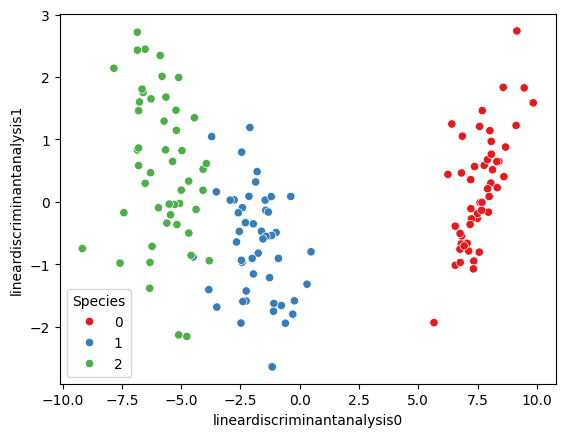

In [30]:
sns.scatterplot(data = lda_data, x = 'lineardiscriminantanalysis0', y = 'lineardiscriminantanalysis1', hue = 'Species',palette='Set1')